In [110]:
import pandas as pd
from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [111]:
data = pd.read_excel('Calidad_del_agua_data.xlsx')

In [112]:
data.head()

,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence,Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Oxygenation Interventions,Corrective Interventions,High Temperature (°C),Low Temperature (°C),Oxygenation Automatic,Thermal Risk Index,Low Oxygen Alert,Health Status
0,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable
1,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
2,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1,0,33.9,24.1,Yes,Normal,Safe,Stable
3,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
4,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable


In [113]:
report = data.profile_report(html={'style':{'full_width':True}})
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [114]:
data.head()

,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence,Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Oxygenation Interventions,Corrective Interventions,High Temperature (°C),Low Temperature (°C),Oxygenation Automatic,Thermal Risk Index,Low Oxygen Alert,Health Status
0,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable
1,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
2,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1,0,33.9,24.1,Yes,Normal,Safe,Stable
3,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,No,Normal,Safe,Stable
4,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,0,0,33.9,24.1,Yes,Normal,Safe,Stable


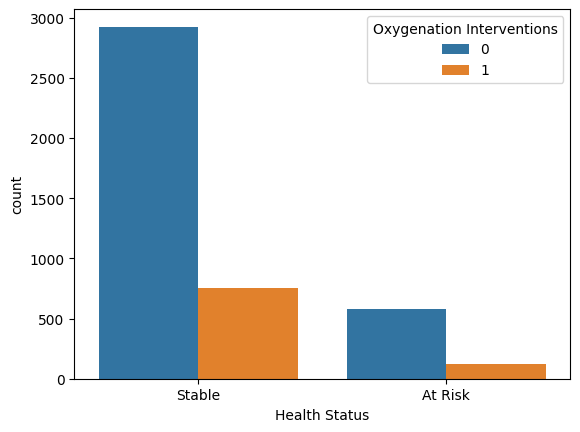

In [115]:
sns.countplot(x='Health Status', hue='Oxygenation Interventions', data=data)
plt.show()

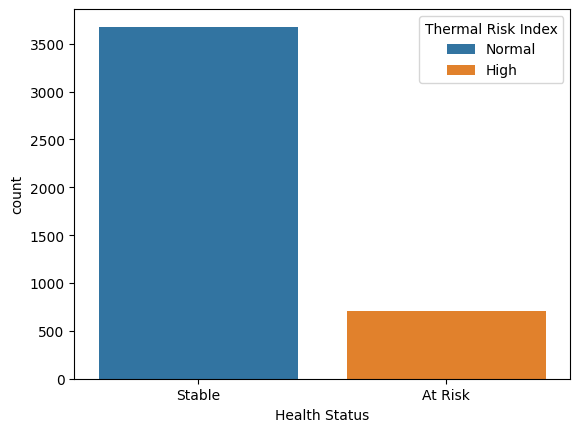

In [116]:
sns.countplot(x='Health Status', hue='Thermal Risk Index', data=data)
plt.show()

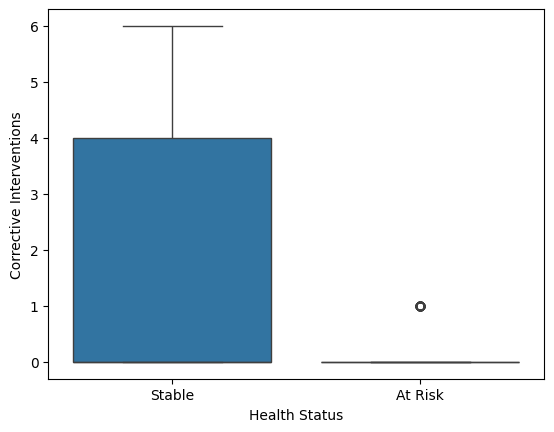

In [117]:
sns.boxplot(x='Health Status', y='Corrective Interventions', data=data)
plt.show()

### Variable objetivo: Health Status

### Análisis preliminar variable por variable:

- Low Oxigen Alert: Constante, se puede eliminar
- Low Temperature, Hight Temperature: Constante, se puede eliminar
- Month: Variable categórica, podemos eliminar. las columnas que tienen valor julio se tomará como si hubieran sido a principios de més tal que puedan considerarse como Junio, dado la baja representación de este mes.
- Average Fish Weight: No se encontró ningúna peculiaridad con esta variable.
- Survival Rate: No se encontró ninguna particularidad con esta variable.
- Desease occurrance: Solo toma dos valores, 1 y 2, dos está muy subrepresentado, por lo que se puede eliminar la columna
- Dissolved Oxygen: No se ve ninguna peculiaridad en estos datos
- pH: No se ve ninguna peculiaridad con esta variable
- Turbidity: De acuerdo con internet, el agua limpia toma valores de turbiedad de 0, tiene sentido que esté mayor a 0, pero que no sea muy alto.
- Oxigenation interventions: Categórica, se tratará como tal, como vemos, no hay ninguna correlación, por lo que se puede eliminar
- Corrective Interventions: No hay peculiaridades con la variable. Sin embargo, al tener tantos ceros, se propone verificar como esta afecta a la variable objetivo. Según se ve, cuando el agua suele estar en riesgo, no tiene mucho riesgo, por lo tanto, se propone conservarla
- Oxigenation automatic: Se deja la variable, no tiene particularidades
- Thermal risk index: Tiene una correlación al 100% con la variable objetivo y sirve para definirla, se va a eliminar
- Health Status: Altamente desbalanceada, se considerará hacer rebalanceo

# Separación de datos

In [118]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [119]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

def transform_months(X):
    X = X.copy()
    if 'Month' in X.columns:
        X['Month'] = X['Month'].replace('July', 'June')
    return X

columns_to_drop = [
    'Low Oxygen Alert', 
    'Low Temperature (°C)', 
    'High Temperature (°C)', 
    'Disease Occurrence', 
    'Oxygenation Interventions', 
    'Thermal Risk Index'
]

data_preparation = Pipeline(steps=[
    ('month_transform', FunctionTransformer(transform_months, feature_names_out='one-to-one')),
    ('drop_columns', ColumnTransformer([
        ('drop', 'drop', columns_to_drop)
    ], remainder='passthrough', verbose_feature_names_out=False)),
])

train_transformed = data_preparation.fit_transform(train)

column_names = [col for col in train.columns if col not in columns_to_drop]
train_transformed = pd.DataFrame(train_transformed, columns=column_names)


In [120]:
# Asegurar que X_train sea un DataFrame
X_train = train.drop(columns=['Health Status'])
y_train = train['Health Status']


In [121]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

def fix_cat_values(df):
  for column in df.columns:
    if column == 'Month':
        df['Month'] = df['Month'].replace('July', 'June')
  return df

num_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# cat_transformer aplica de primer paso nuestra funcion complementaria y luego sobre ese resultado aplica OneHotEncoder
cat_transformer = Pipeline(
    steps=[
        ('fix-vals', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [122]:
import numpy as np
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", cat_transformer, make_column_selector(dtype_include=object)),
        ('drop', 'drop', columns_to_drop)
    ]
)

In [123]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.svm import SVC

pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(random_state=42, kernel='rbf'))
], verbose=True)


In [124]:
param_grid = {
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()],
    'preprocessor__cat__encoder': [OneHotEncoder(handle_unknown='ignore'), OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['rbf']
}

In [125]:
from sklearn.model_selection import GridSearchCV

# GridSearch con verbose para ver qué está fallando
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=2, error_score='raise')
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] ............... (step 3 of 3) Processing svm, total=   0.0s
[CV] END preprocessor__cat__encoder=OneHotEncoder(handle_unknown='ignore'), preprocessor__num__scaler=StandardScaler(), svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.1s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] ............... (step 3 of 3) Processing svm, total=   0.0s
[CV] END preprocessor__cat__encoder=OneHotEncoder(handle_unknown='ignore'), preprocessor__num__scaler=StandardScaler(), svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s

GridSearchCV(cv=3, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x157bc73b0>),
                                                                        ('cat',
                                                                         Pipeline(steps=[('fix-vals',
                                                                                          FunctionTransformer(func=<function fix_cat_values at 0x165d10540>)),
                                                                                         ('enco...
                                       ('svm', SVC(random_state=42))],
                                verbose=True),
             param_grid={'preprocessor__cat__encoder': [OneHotEncoder(handle_unknown='ignore'),
                                                        OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                       unknown_value=-1)],
                         'preprocessor__num__scaler': [StandardScaler(),
                                                       MinMaxScaler()],
                         'svm__C': [0.1, 1, 10],
                         'svm__gamma': ['scale', 'auto'],
                         'svm__kernel': ['rbf']},
             scoring='accuracy', verbose=2)

In [126]:
best_model = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)
print("Exactitud en entrenamiento:", grid_search.best_score_)

Mejores parámetros: {'preprocessor__cat__encoder': OneHotEncoder(handle_unknown='ignore'), 'preprocessor__num__scaler': StandardScaler(), 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Exactitud en entrenamiento: 1.0


In [127]:
a = test.iloc[1:2]
X_a = a.drop('Health Status', axis=1)
y_a = a['Health Status']

y_pred = best_model.predict(X_a)

In [128]:
a = test[test['Health Status'] == 'At Risk'][0:1]
X_a = a.drop('Health Status', axis=1)
y_a = a['Health Status']

y_pred = best_model.predict(X_a)

In [129]:
y_pred

array(['At Risk'], dtype=object)

In [130]:
from sklearn.tree import DecisionTreeClassifier

# cat_transformer aplica de primer paso nuestra funcion complementaria y luego sobre ese resultado aplica OneHotEncoder
cat_transformer_tree = Pipeline(
    steps=[
        ('fix-vals', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer_tree, make_column_selector(dtype_include=object)),
        ('drop', 'drop', columns_to_drop)
    ]
)

pipeline_tree = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('smote', SMOTE(random_state=42)),  # Ya debería recibir un numpy.ndarray
    ('tree', DecisionTreeClassifier(random_state=42))
], verbose=True)

In [131]:
param_grid = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [None, 10, 20, 30],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__max_features': [None, 'sqrt', 'log2']
}

# GridSearch con verbose para ver qué está fallando
grid_search_tree = GridSearchCV(pipeline_tree, param_grid, cv=3, scoring='accuracy', verbose=2, error_score='raise')
grid_search_tree.fit(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=None, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0s
[CV] END tree__criterion=gini, tree__max_depth=None, tree__max_features=None, tree__min_samples_leaf=1, tree__min_samples_split=2; total time=   0.0s
[Pipeline] ...... (step 1 of 3) Processing preprocessor, total=   0.0s
[Pipeline] ............. (step 2 of 3) Processing smote, total=   0.0s
[Pipeline] .............. (step 3 of 3) Processing tree, total=   0.0

GridSearchCV(cv=3, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('fix-vals',
                                                                                          FunctionTransformer(func=<function fix_cat_values at 0x165d10540>)),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x157dba9c0>),
                                                                        ('drop...
                                                                          'Interventions',
                                                                          'Thermal '
                                                                          'Risk '
                                                                          'Index'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('tree',
                                        DecisionTreeClassifier(random_state=42))],
                                verbose=True),
             param_grid={'tree__criterion': ['gini', 'entropy'],
                         'tree__max_depth': [None, 10, 20, 30],
                         'tree__max_features': [None, 'sqrt', 'log2'],
                         'tree__min_samples_leaf': [1, 2, 4],
                         'tree__min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=2)

In [132]:
best_model_tree = grid_search_tree.best_estimator_
print("Mejores parámetros:", grid_search_tree.best_params_)
print("Exactitud en entrenamiento:", grid_search_tree.best_score_)

Mejores parámetros: {'tree__criterion': 'gini', 'tree__max_depth': None, 'tree__max_features': None, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Exactitud en entrenamiento: 1.0


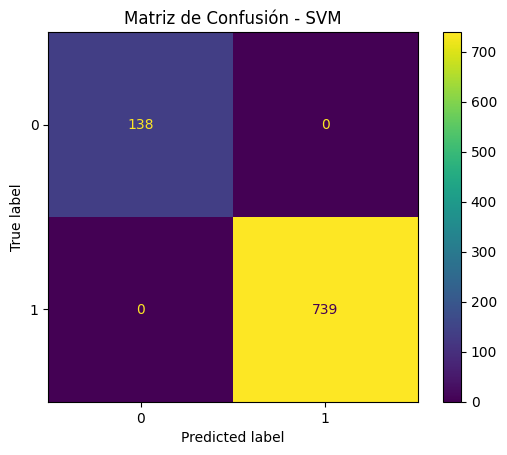

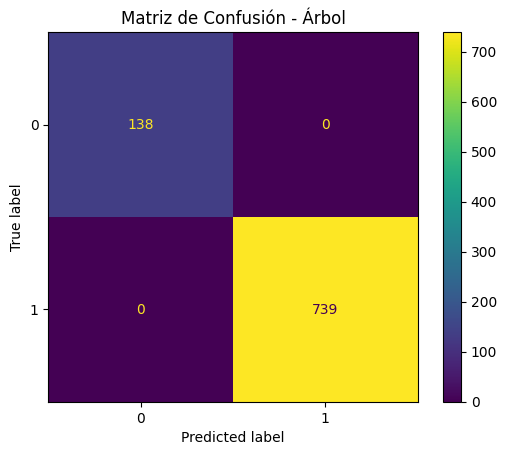

In [142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_test = test.drop(columns=['Health Status'])
y_test = test['Health Status']

# Predicciones para el conjunto de prueba con el modelo SVM
y_pred_svm = best_model.predict(X_test)

#Predicciones para el conjunto de prueba con el modelo de árbol
y_pred_tree = best_model_tree.predict(X_test)

# Matriz de confusión para el modelo SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot()
plt.title("Matriz de Confusión - SVM")
plt.show()

# Matriz de confusión para el modelo de árbol
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp_tree.plot()
plt.title("Matriz de Confusión - Árbol")
plt.show()